# Pilot v2 evaluation

What this notebook does: read the aggregated judge output in `data/pilot_v2_eval` and work out what the pilot can and cannot tell us about the evaluated model.

**The model under test.** Llama 3.1 70B, recorded as `llama3.1:70b` in the `response_metadata` of every inference record. It is the same model for all 900 records, and every finding below is about that one model. [`pilot_v2_leakage_subsets.ipynb`](pilot_v2_leakage_subsets.ipynb) reads the tag out of the raw records and asserts it is uniform, so this does not have to be taken on trust.

**The data.** 180 base items, each translated into 5 languages, giving 900 rows. Every item belongs to one of six perturbation classes and one of three intensities, 10 items per language x class x intensity cell. That cell is what `metrics_by_stratum.csv` calls a *stratum*.

**All 900 items are perturbed, including the answerable ones.** Every record carries a `lever_selected`, at all three intensities. What changes with intensity is how severe the defect is, and therefore what the model is supposed to do about it. The RefusalBench paper defines the progression in section 3.3: LOW introduces "subtle uncertainty that a competent model should resolve and answer correctly, testing for over-sensitive refusal", while MEDIUM creates a clear informational deficit and HIGH a severe one, both requiring refusal. So every LOW item is answerable and carries `expected_behavior: ANSWER_CORRECTLY`, and every MEDIUM and HIGH item is unanswerable.

This matters for how the answerable side is read. A LOW item is not a clean question. It is a deliberately baited one that happens to remain answerable. A LOW FalsePremise item, for example, asks for a fact that the context does supply, inside a query that presupposes something false: *"Who is the CEO of InnoTech, the Google subsidiary?"* where the context says only that InnoTech's CEO is John Doe and never mentions Google. The benchmark's ground truth is to answer the answerable part. Section 6 returns to this.

Each perturbation class maps to exactly one refusal code: MissingInfo to `REFUSE_INFO_MISSING_IN_CONTEXT`, GranularityMismatch to `REFUSE_GRANULARITY_MISMATCH`, EpistemicMismatch to `REFUSE_NONFACTUAL_QUERY`, and so on, one to one. So "which perturbation class" and "which refusal code is correct" are the same question asked twice.

**Six categories in the paper, seven labels in our scoring.** RefusalBench section 3.2 defines six categories of informational uncertainty and one expected refusal code for each, under shorter names (`REFUSE_MISSING`, `REFUSE_GRANULARITY`, `REFUSE_NONFACTUAL` and so on). `refusalbench.multilingual.aggregate.VALID_REFUSAL_CODES` spells those six out at greater length and adds a seventh, `REFUSE_OTHER`, which the paper's taxonomy does not define. It is never the ground truth for any item here and the model never emits it, so it costs nothing. It does mean that the phrase "exact seven-way code match" below describes our scoring code rather than the benchmark.

**Metric definitions** (from `refusalbench.multilingual.aggregate.compute_metrics_block`):

| metric | population | denominator | definition |
|---|---|---|---|
| `answer_accuracy` | answerable items | successes / *n* answerable in the slice | model attempted an answer **and** consensus quality is at least 4 |
| `refusal_accuracy` | unanswerable items | successes / *n* unanswerable in the slice | model refused **and** the refusal code exactly matches ground truth |
| `false_refusal_rate` | answerable items | refusals / *n* answerable in the slice | model emitted any refusal code |
| `missed_refusal_rate` | unanswerable items | answer attempts / *n* unanswerable in the slice | model attempted an answer |
| `calibrated_refusal_score` | both | none (see below) | unweighted mean of `answer_accuracy` and `refusal_accuracy` |

Rates are **proportions on 0-1**: 0.30 means 30% of the denominator population. The denominator changes with the slice, so a full language column has 60 answerable and 120 unanswerable rows while a LOW-only slice has 60 answerable and 0 unanswerable. `calibrated_refusal_score` is not one fraction. It averages two rates that use different denominators with equal weight.

Note the asymmetry in row 2: a refusal with the wrong code scores exactly zero, the same as not refusing at all. Section 4 shows why that matters more than it sounds.

The last row is the one to watch. `calibrated_refusal_score` is only meaningful on a slice that contains **both** answerable and unanswerable items.

On pure slices (only answerable or only unanswerable), the absent component and the calibrated score are undefined. Section 1 shows why that matters for this pilot.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from refusalbench.multilingual.aggregate import (
    ANSWER_CORRECTLY,
    VALID_REFUSAL_CODES,
    compute_metrics_block,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)

REPO = Path.cwd()

if not (REPO / "data" / "pilot_v2_eval").is_dir():
    REPO = REPO.parent

EVAL = REPO / "data" / "pilot_v2_eval"

consensus = pd.read_csv(EVAL / "consensus.csv")
metrics_lang = pd.read_csv(EVAL / "metrics_by_language.csv")
metrics_stratum = pd.read_csv(EVAL / "metrics_by_stratum.csv")
judge_agreement = pd.read_csv(EVAL / "judge_agreement.csv")
failures = pd.read_csv(EVAL / "failures.csv")

JUDGES = ["mistral-large-3", "nemotron-3-super", "sonnet4_5"]
CONSENSUS = "consensus"

consensus["answerable"] = consensus["ground_truth_label"].eq(ANSWER_CORRECTLY)
answerable = consensus[consensus["answerable"]]
unanswerable = consensus[~consensus["answerable"]]

print(f"loaded {len(consensus)} consensus items from {EVAL}")
print(f"judge call failures: {len(failures)}")
print(f"items with no judge majority: {int(consensus['no_majority'].sum())}")
print(f"answerable / unanswerable: {len(answerable)} / {len(unanswerable)}")

loaded 900 consensus items from /Users/artem/Work/refusalbench/data/pilot_v2_eval
judge call failures: 0
items with no judge majority: 0
answerable / unanswerable: 300 / 600


## 1. The design, and the constraint it imposes

The pilot is fully balanced. Before reading any metric it is worth seeing how answerability is distributed, because that determines which comparisons are legitimate.

In [ ]:
design = pd.crosstab(consensus["intensity"], consensus["answerable"])
design.columns = ["unanswerable", "answerable"]
design = design.loc[["LOW", "MEDIUM", "HIGH"]]
print("items by intensity and answerability")
print(design.to_string())
print()

cell_sizes = consensus.groupby(["language", "perturbation_class", "intensity"]).size()
print(f"{consensus['language'].nunique()} languages x "
      f"{consensus['perturbation_class'].nunique()} perturbation classes x "
      f"{consensus['intensity'].nunique()} intensities")
print(f"cell size: min {cell_sizes.min()}, max {cell_sizes.max()}, {len(cell_sizes)} cells")

items by intensity and answerability
           unanswerable  answerable
intensity                          
LOW                   0         300
MEDIUM              300           0
HIGH                300           0

5 languages x 6 perturbation classes x 3 intensities
cell size: min 10, max 10, 90 cells


**Answerability is perfectly confounded with intensity.** LOW is the answerable stratum and carries all 300 answerable items. MEDIUM and HIGH carry all 600 unanswerable items.

This confound is inherited from the parent benchmark rather than introduced here. RefusalBench section 3.3 specifies exactly this: answer correctly at LOW, refuse at MEDIUM and HIGH. Removing it would mean departing from the benchmark's own design, which is a deliberate choice to make rather than a bug to fix.

Two consequences, both load bearing for the rest of the notebook:

1. `calibrated_refusal_score` must never be compared across intensities, and must never be read off a single row of `metrics_by_stratum.csv`. Every stratum row in this pilot is *pure*, holding only answerable items or only unanswerable ones and never both, so one of the two components is undefined.

2. Any statement of the form "difficulty rises with intensity" is really a statement about two different metrics measured on two different item populations.

In [ ]:
def wilson(successes, n, z=1.96):
    """Wilson score interval, which behaves at the small counts this pilot produces."""
    if n == 0:
        return (np.nan, np.nan)
    _p = successes / n
    denom = 1 + z * z / n
    centre = (_p + z * z / (2 * n)) / denom
    half = z * np.sqrt(_p * (1 - _p) / n + z * z / (4 * n * n)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))
by_intensity = pd.DataFrame([{'intensity': k, **compute_metrics_block(_g)} for k, _g in consensus.groupby('intensity')]).set_index('intensity').loc[['LOW', 'MEDIUM', 'HIGH']]
cols = ['num_answerable', 'num_unanswerable', 'answer_accuracy', 'refusal_accuracy', 'calibrated_refusal_score']
print('metrics by intensity (undefined where the population is empty)')
print(by_intensity[cols].round(3).to_string())
stratum = metrics_stratum[metrics_stratum['judge_id'] == CONSENSUS]
pure = ((stratum['num_answerable'] == 0) | (stratum['num_unanswerable'] == 0)).mean()
_lo, _hi = wilson(5, 10)
print()
print(f"stratum rows: {len(stratum)} of {int(stratum['n'].min())} items each, {pure:.0%} pure")
print(f"  calibrated_refusal_score is NaN in {stratum['calibrated_refusal_score'].isna().mean():.0%} of them")
# the same purity holds one level down, which is what settles how fine a slice
# metrics_by_stratum.csv can support, so it is settled here rather than in its own section.
print(f'  a 5/10 cell carries a 95% interval of [{_lo:.2f}, {_hi:.2f}], width {_hi - _lo:.2f}')

metrics by intensity (undefined where the population is empty)
           num_answerable  num_unanswerable  answer_accuracy  refusal_accuracy  calibrated_refusal_score
intensity                                                                                               
LOW                 300.0               0.0             0.55               NaN                       NaN
MEDIUM                0.0             300.0              NaN             0.263                       NaN
HIGH                  0.0             300.0              NaN             0.350                       NaN

stratum rows: 90 of 10 items each, 100% pure
  calibrated_refusal_score is NaN in 100% of them
  a 5/10 cell carries a 95% interval of [0.24, 0.76], width 0.53


LOW is answer accuracy on answerable items only.

MEDIUM and HIGH are refusal accuracy on unanswerable items only.

Those three numbers are not on a common scale, so do not rank intensities by calibrated score or by mixing the columns.

**The same purity holds all the way down.** All 90 rows of `metrics_by_stratum.csv` are pure, so every calibrated score in that file is undefined, and at 10 items per cell a 95 percent interval is about half the scale wide. Nothing at that granularity separates from anything else. Treat that file as a check on design balance and nothing more. Language slices at n=180 and perturbation slices at n=150 are the finest that support a claim here, and even those only marginally.

Section 7 makes the intensity comparison the data does support.

## 2. Are the judges reliable enough to pool?

All model metrics below are computed on the majority label across three judges, so this question comes first.

We use two inter-judge checks on different outputs (from `judge_agreement.csv`):

- **Cohen κ / Fleiss κ (refusal code)**: Do judges assign the **same label**, beyond what chance would predict given how often each label is used? Cohen κ is pairwise and Fleiss κ summarises all three judges on classification.

- **Spearman ρ (answer quality, 1-5)**: If one judge rates an item higher, do the others tend to rate it higher too (**rank alignment**)? Pairwise only.

These answer different questions.

The chart below puts both on a 0-1 axis for a quick visual contrast, not as a single comparable "agreement score".

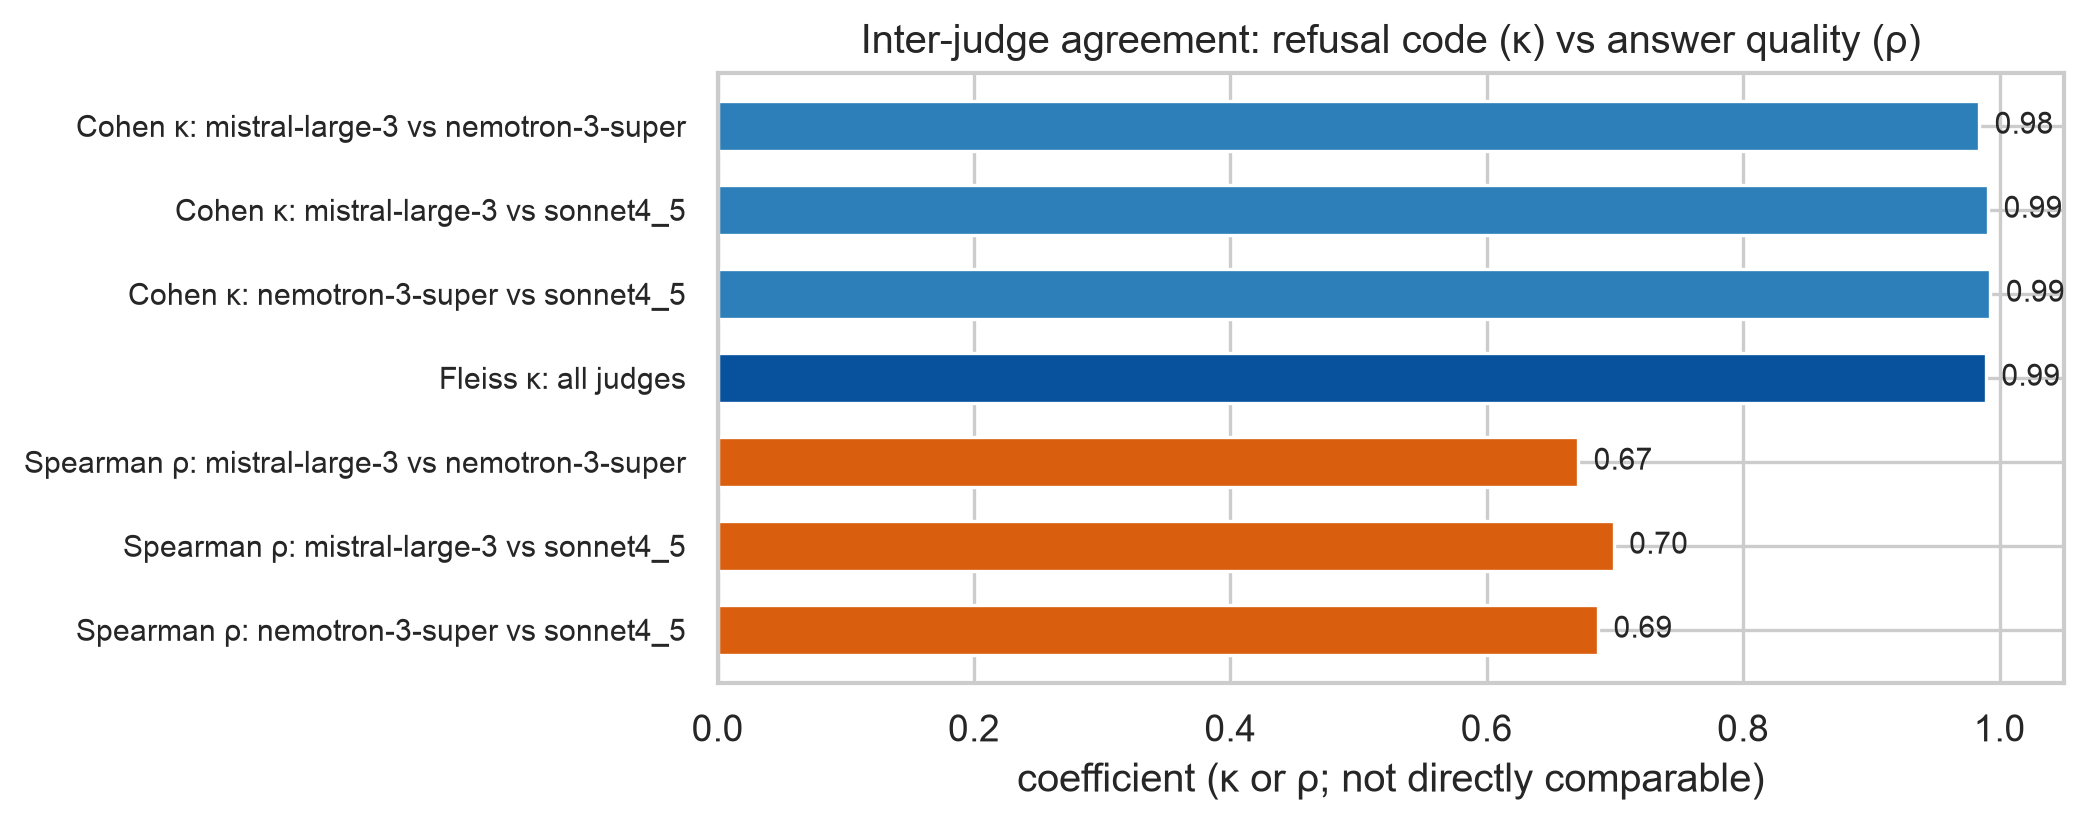

classification kappa: 0.984 to 0.993
quality spearman:     0.671 to 0.699
quality mean absolute difference: 0.33 points on a 1 to 5 scale


In [ ]:
overall = judge_agreement[judge_agreement['scope'] == 'overall'].copy()

def _judge_pair_label(row: pd.Series) -> str:
    if row['judge_b'] == 'all':
        return 'all judges'
    return f"{row['judge_a']} vs {row['judge_b']}"
cohen = overall[overall['metric'] == 'classification_cohen_kappa'].copy()
fleiss = overall[overall['metric'] == 'classification_fleiss_kappa'].copy()
spearman = overall[overall['metric'] == 'quality_spearman'].copy()
cohen['label'] = 'Cohen κ: ' + cohen.apply(_judge_pair_label, axis=1)
fleiss['label'] = 'Fleiss κ: all judges'
spearman['label'] = 'Spearman ρ: ' + spearman.apply(_judge_pair_label, axis=1)
plot_rows = pd.concat([cohen, fleiss, spearman], ignore_index=True)
colour_map = {'classification_cohen_kappa': '#2c7fb8', 'classification_fleiss_kappa': '#08519c', 'quality_spearman': '#d95f0e'}
# figure: 01-judge-agreement
_fig, _ax = plt.subplots(figsize=(8.8, 3.6))
labels = list(plot_rows['label'])
values = list(plot_rows['value'])
colours = [colour_map[m] for m in plot_rows['metric']]
_y = np.arange(len(labels))[::-1]
_ax.barh(_y, values, color=colours, height=0.6)
for _yi, _v in zip(_y, values):
    _ax.text(_v + 0.012, _yi, f'{_v:.2f}', va='center', fontsize=9)
_ax.set_yticks(_y, labels, fontsize=9)
_ax.set_xlim(0, 1.05)
_ax.set_xlabel('coefficient (κ or ρ; not directly comparable)')
_ax.set_title('Inter-judge agreement: refusal code (κ) vs answer quality (ρ)')
plt.tight_layout()
plt.show()
kappa_vals = pd.concat([cohen['value'], fleiss['value']])
print('classification kappa: %.3f to %.3f' % (kappa_vals.min(), kappa_vals.max()))
print('quality spearman:     %.3f to %.3f' % (spearman['value'].min(), spearman['value'].max()))
print('quality mean absolute difference: %.2f points on a 1 to 5 scale' % overall.loc[overall['metric'] == 'quality_mean_abs_diff', 'value'].mean())

- **Refusal code classification is effectively solved.** Cohen κ 0.984 to 0.993, Fleiss κ 0.990, raw agreement above 99 percent. Consensus labels are safe to pool.

- **Answer quality is not.** Spearman ρ 0.67 to 0.70 and judges differ by about a third of a point on the 1 to 5 scale.

This split matters because `answer_accuracy` is gated on quality being at least 4. The next cell checks how much of the metric variance that gate actually causes.

In [ ]:
per_judge = metrics_lang[metrics_lang['judge_id'].isin(JUDGES)]
spread = {}
for _metric in ['answer_accuracy', 'refusal_accuracy', 'calibrated_refusal_score']:
    _wide = per_judge.pivot(index='language', columns='judge_id', values=_metric)
    spread[_metric] = _wide.max(axis=1) - _wide.min(axis=1)
spread = pd.DataFrame(spread)
print('range across the three judges, within each language')
print(spread.round(3).to_string())
print()
print('largest judge-driven swing in calibrated score: %.3f' % spread['calibrated_refusal_score'].max())

range across the three judges, within each language
          answer_accuracy  refusal_accuracy  calibrated_refusal_score
language                                                             
en                  0.100             0.008                     0.046
pl                  0.100             0.008                     0.050
ru                  0.083             0.008                     0.042
zh_cmn              0.100             0.000                     0.050
zh_yue              0.117             0.000                     0.058

largest judge-driven swing in calibrated score: 0.058


Judge disagreement is confined almost entirely to `answer_accuracy` (up to 0.117 range within a language) while `refusal_accuracy` is stable to within 0.008.

Because the calibrated score averages the two, swapping judges moves it by up to 0.058. Section 5 compares this to the language gaps.

## 3. Where do the 900 items land?

One picture of every item, before slicing anything.

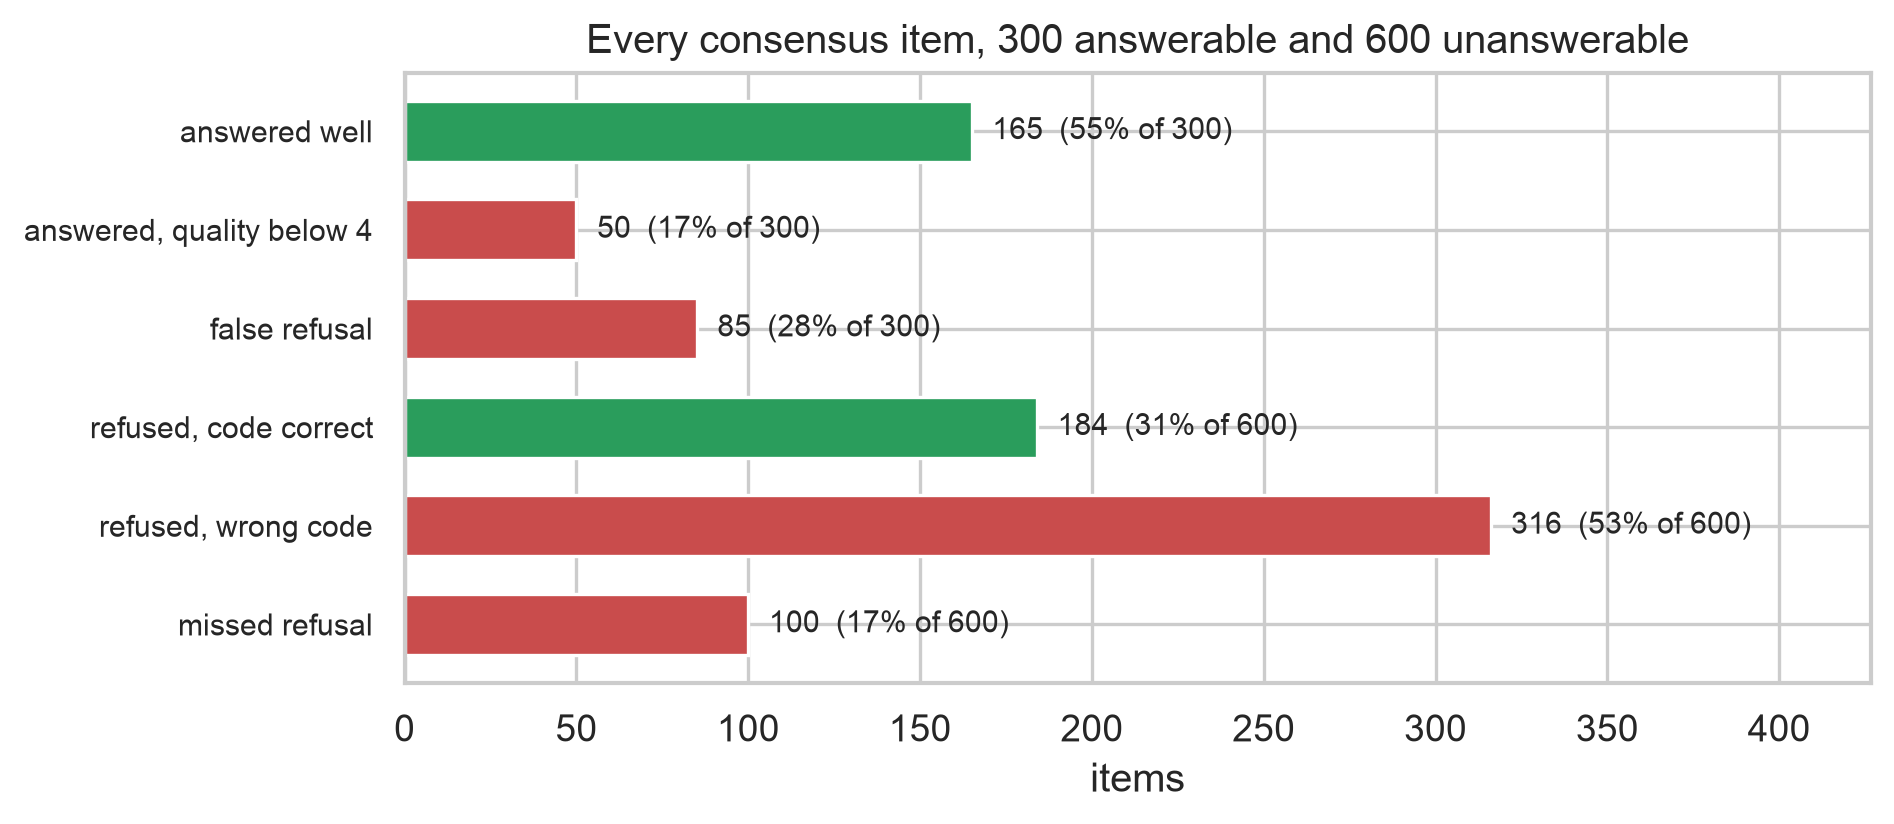

overall calibrated score: 0.428


In [ ]:
REFUSAL_CODES = set(VALID_REFUSAL_CODES)

def outcome(row):
    """Label each item from the structured dual-eval fields."""
    if row['answerable']:
        if row['model_predicted_type'] in REFUSAL_CODES:
            return 'false refusal'
        quality = row['answer_quality_score']
        if pd.notna(quality) and quality >= 4:
            return 'answered well'
        return 'answered, quality below 4'
    if row['model_predicted_type'] == 'answer_attempt':
        return 'missed refusal'
    if row['refusal_match_correct']:
        return 'refused, code correct'
    return 'refused, wrong code'
consensus['outcome'] = consensus.apply(outcome, axis=1)
ORDER = ['answered well', 'answered, quality below 4', 'false refusal', 'refused, code correct', 'refused, wrong code', 'missed refusal']
GOOD = {'answered well', 'refused, code correct'}
counts = consensus['outcome'].value_counts().reindex(ORDER)  # noqa: E712
# figure: 02-all-900-items
_fig, _ax = plt.subplots(figsize=(8, 3.6))
_y = np.arange(len(ORDER))[::-1]
_ax.barh(_y, counts.values, color=['#2a9d5c' if o in GOOD else '#c94c4c' for o in ORDER], height=0.62)
for _yi, o, _v in zip(_y, ORDER, counts.values):
    base = 300 if o in ('answered well', 'answered, quality below 4', 'false refusal') else 600
    _ax.text(_v + 6, _yi, f'{_v}  ({_v / base:.0%} of {base})', va='center', fontsize=9)
_ax.set_yticks(_y, ORDER, fontsize=9)
_ax.set_xlim(0, counts.max() * 1.35)
_ax.set_xlabel('items')
_ax.set_title('Every consensus item, 300 answerable and 600 unanswerable')
plt.tight_layout()
plt.show()
# the full 900 items carry both populations, so the calibrated score is defined here
print('overall calibrated score: %.3f' % compute_metrics_block(consensus)['calibrated_refusal_score'])

Reading the two populations separately:

- **Answerable (300).** 165 answered well, 50 answered but scored below the quality gate, 85 refused outright. So the model gives up on 28 percent of questions it should answer.

- **Unanswerable (600).** 184 refused with the correct code, 316 refused with the wrong code, 100 answered anyway. The model almost always recognises that something is wrong (500 of 600) and then usually picks the wrong reason.

Wrong-code refusals are the single largest bucket in the whole pilot. Section 4 asks what they turn into.

## 4. The refusal codes collapse onto one label

Section 3 left 316 wrong-code refusals unexplained. This section asks what the model says instead of the right reason.

`refusal_accuracy` requires an **exact match** on the refusal code, one of seven. So the question is whether the model chooses among the seven reasons, or reaches for the same one whatever the item.

The heatmap reads one row per true reason, one column per label the model actually produced, each row normalised to sum to 1. A model that tells the reasons apart puts its mass on the **diagonal**. A model with one favourite code puts its mass in one **column**.

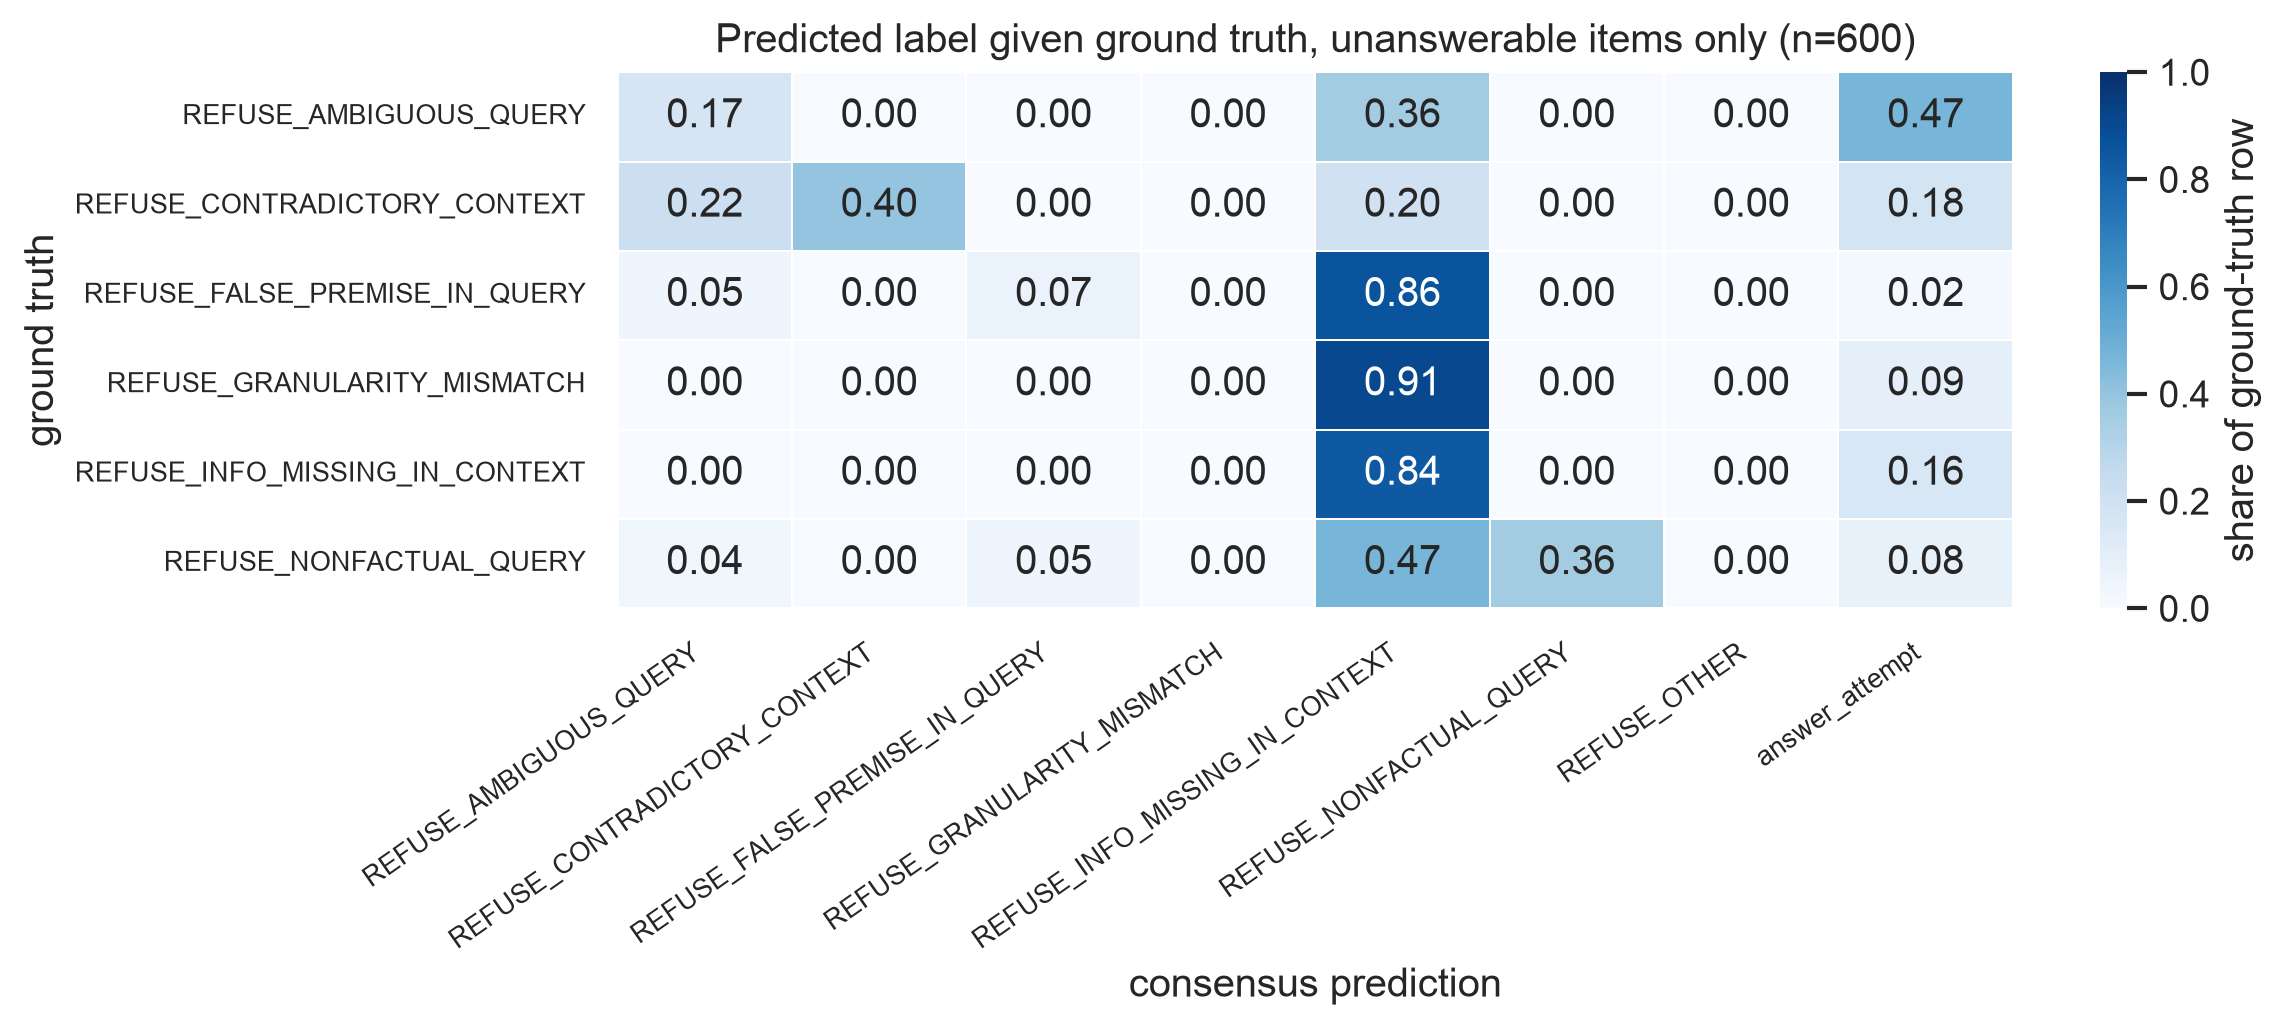

refusal codes the model never produces, across all 900 items:
   REFUSE_GRANULARITY_MISMATCH
   REFUSE_OTHER

share of unanswerable predictions that are REFUSE_INFO_MISSING_IN_CONTEXT: 0.607
share of unanswerable ground truth that is REFUSE_INFO_MISSING_IN_CONTEXT:  0.167
share of all 900 predictions that are REFUSE_INFO_MISSING_IN_CONTEXT:        0.488

observed refusal_accuracy:                        0.307
refusal_accuracy of a constant INFO_MISSING guess: 0.167


In [ ]:
conf = pd.crosstab(unanswerable['ground_truth_label'], unanswerable['model_predicted_type'], normalize='index')
row_order = list(conf.index)
# order columns to match the rows so the diagonal reads as the diagonal
col_order = row_order + [_c for _c in VALID_REFUSAL_CODES if _c not in row_order] + ['answer_attempt']
conf = conf.reindex(columns=col_order, fill_value=0.0)
# figure: 03-refusal-code-collapse
_fig, _ax = plt.subplots(figsize=(10, 4.4))
sns.heatmap(conf, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=_ax, cbar_kws={'label': 'share of ground-truth row'}, linewidths=0.5, linecolor='white')
_ax.set_title('Predicted label given ground truth, unanswerable items only (n=600)')
_ax.set_xlabel('consensus prediction')
_ax.set_ylabel('ground truth')
plt.setp(_ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
plt.setp(_ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
never = sorted(set(VALID_REFUSAL_CODES) - set(consensus['model_predicted_type']))
print('refusal codes the model never produces, across all 900 items:')
for _c in never:
    print('  ', _c)
print()
print('share of unanswerable predictions that are REFUSE_INFO_MISSING_IN_CONTEXT: %.3f' % unanswerable['model_predicted_type'].eq('REFUSE_INFO_MISSING_IN_CONTEXT').mean())
print('share of unanswerable ground truth that is REFUSE_INFO_MISSING_IN_CONTEXT:  %.3f' % unanswerable['ground_truth_label'].eq('REFUSE_INFO_MISSING_IN_CONTEXT').mean())
# the paper quotes this label's share of *all* predictions, so compute that too
# rather than comparing our unanswerable-only share against a different denominator.
print('share of all 900 predictions that are REFUSE_INFO_MISSING_IN_CONTEXT:        %.3f' % consensus['model_predicted_type'].eq('REFUSE_INFO_MISSING_IN_CONTEXT').mean())
print()
print('observed refusal_accuracy:                        %.3f' % unanswerable['refusal_match_correct'].eq(True).mean())
print('refusal_accuracy of a constant INFO_MISSING guess: %.3f' % unanswerable['ground_truth_label'].eq('REFUSE_INFO_MISSING_IN_CONTEXT').mean())

The matrix is close to a single vertical stripe.

Codes are shortened below.

`INFO_MISSING` is `REFUSE_INFO_MISSING_IN_CONTEXT`.

- `INFO_MISSING` absorbs **61 percent** of all predictions on unanswerable items (364 of 600), against a ground-truth prevalence of 17 percent (100 of 600). Of the 500 items the model did refuse, 73 percent got that one code.

- `GRANULARITY_MISMATCH` is **never emitted once in 900 items**, and it is the ground truth for 100 of them. Those items score 0.00 refusal accuracy by construction, not because they are hard in any graded sense. `REFUSE_OTHER` is never emitted either, but it is never the ground truth, so nothing is lost there.

- The off-diagonal mass runs one way. False-premise items are called `INFO_MISSING` 86 percent of the time, granularity items 91 percent.

- Only three rows hold real diagonal mass: `INFO_MISSING` itself (0.84, which is the collapse working in its favour), `CONTRADICTORY_CONTEXT` (0.40) and `NONFACTUAL_QUERY` (0.36).

**Why the baseline is 0.167.** A model that refused every unanswerable item with `INFO_MISSING` and nothing else would still be right 100 times out of 600, because that is how often `INFO_MISSING` happens to be the correct code. Observed accuracy is 0.307. The model beats the degenerate one-code strategy, but by a margin a 7-way task should dwarf.

**This is the paper's finding, reproduced more severely, and the denominators have to match before the two numbers are put side by side.** RefusalBench section 4.2, under *Systematic Misclassification of Refusal Types*, reports that models default to `REFUSE_INFO_MISSING` as a catch-all receiving 25 percent of **all** predictions on RefusalBench-NQ, averaged over every model it evaluates, with granularity and ambiguity items frequently misclassified as missing information. Our comparable figure is 49 percent of all 900 predictions. The 61 percent above is the share restricted to unanswerable items, which is the more diagnostic slice but is not what the paper quotes. On either denominator this model leans on the catch-all far harder than the paper's average, and it never emits `GRANULARITY_MISMATCH` at all, which the paper calls nearly unsolvable with a best observed score of 31.1 percent (section 4.2 and appendix F.4). The pattern is the paper's. Only its severity is ours.

**What this costs the rest of the notebook.** `refusal_accuracy` here is not measuring graded refusal skill. It mostly measures how close a slice's ground-truth codes sit to the one code the model actually uses, so every later `refusal_accuracy` figure inherits it. Section 6 is the sharpest case.

## 5. Language

The five language sets are not five samples. They are the **same 180 items**, translated, so the model saw each question five times over, once per language.

That changes which comparison is right. Asking "is the model worse in Polish than in English" as if the two sets were unrelated throws away the fact that they are the same questions. The comparison that uses it asks, item by item: **when this exact question is translated, does the model's behaviour change?**

Both readings follow. The unpaired one comes first, because it is what `metrics_by_language.csv` supports directly and because it is the one that finds nothing.

**One note on the numbers from here on.** Sections 1 to 4 reported counts and shares, which is what the model did. From here the notebook also reports p values and interval widths. Those are a different kind of quantity: they are not model performance, they measure how much of a difference could be luck. Read the counts first and treat the small decimals as corroboration.

In [ ]:
# language slices pool all three intensities, so they carry both populations and
# every metric below is defined. the assert makes that assumption explicit.
lang_rows = []
for lang, _g in consensus.groupby('language'):
    _block = compute_metrics_block(_g)
    _a = _g[_g['answerable']]
    _u = _g[~_g['answerable']]
    _n_ans = int((_a['model_predicted_type'].eq('answer_attempt') & (_a['answer_quality_score'] >= 4)).sum())
    _n_ref = int(_u['refusal_match_correct'].eq(True).sum())
    lo_a, hi_a = wilson(_n_ans, len(_a))
    lo_r, hi_r = wilson(_n_ref, len(_u))
    lang_rows.append({'language': lang, 'answer_accuracy': _block['answer_accuracy'], 'ans_lo': lo_a, 'ans_hi': hi_a, 'refusal_accuracy': _block['refusal_accuracy'], 'ref_lo': lo_r, 'ref_hi': hi_r, 'false_refusal_rate': _block['false_refusal_rate'], 'missed_refusal_rate': _block['missed_refusal_rate'], 'calibrated_refusal_score': _block['calibrated_refusal_score']})
lang = pd.DataFrame(lang_rows).set_index('language').sort_values('calibrated_refusal_score', ascending=False)
assert lang.notna().all().all(), 'language slices should be mixed, so nothing here may be NaN'
print(lang[['answer_accuracy', 'refusal_accuracy', 'false_refusal_rate', 'missed_refusal_rate', 'calibrated_refusal_score']].round(3).to_string())

          answer_accuracy  refusal_accuracy  false_refusal_rate  missed_refusal_rate  calibrated_refusal_score
language                                                                                                      
en                  0.667             0.300               0.150                0.200                     0.483
zh_yue              0.550             0.317               0.350                0.167                     0.433
ru                  0.517             0.333               0.283                0.183                     0.425
zh_cmn              0.517             0.317               0.283                0.142                     0.417
pl                  0.500             0.267               0.350                0.142                     0.383


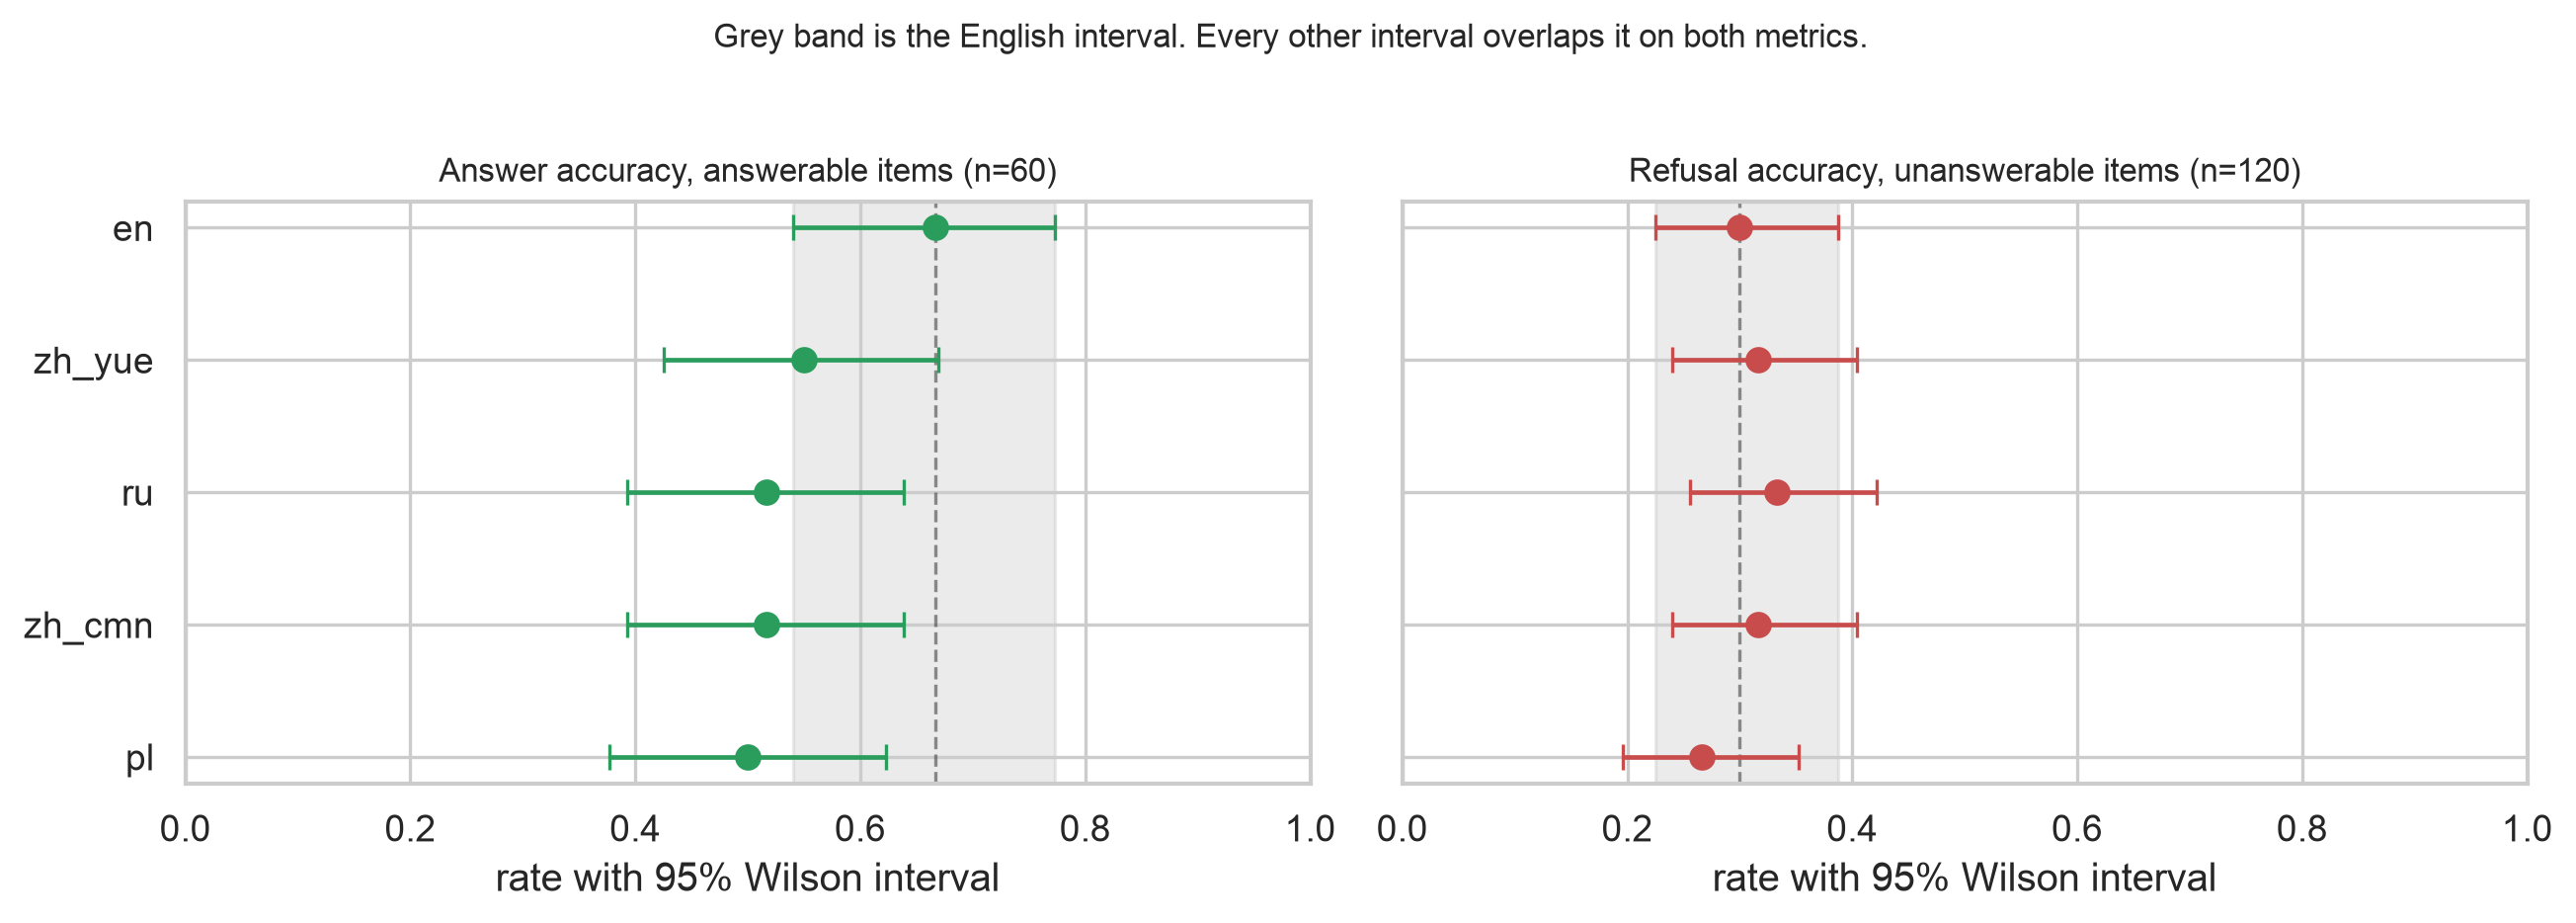

gap vs English in calibrated score, alongside the judge-swap swing of 0.058
language
pl       -0.100
zh_cmn   -0.067
ru       -0.058
zh_yue   -0.050


In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
order = lang.index[::-1]
_y = np.arange(len(order))
for _ax, (_point, _lo, _hi, _title, _colour) in zip(_axes, [('answer_accuracy', 'ans_lo', 'ans_hi', 'Answer accuracy, answerable items (n=60)', '#2a9d5c'), ('refusal_accuracy', 'ref_lo', 'ref_hi', 'Refusal accuracy, unanswerable items (n=120)', '#c94c4c')]):
    _sub = lang.loc[order]
    _ax.axvspan(_sub.loc['en', _lo], _sub.loc['en', _hi], color='#888', alpha=0.16, zorder=0)
    _ax.axvline(_sub.loc['en', _point], color='#444', ls='--', lw=1, alpha=0.6, zorder=1)
    _ax.errorbar(_sub[_point], _y, xerr=[_sub[_point] - _sub[_lo], _sub[_hi] - _sub[_point]], fmt='o', color=_colour, capsize=4, markersize=7, lw=1.4, zorder=2)
    _ax.set_yticks(_y, order)
    _ax.set_xlim(0, 1)
    _ax.set_title(_title, fontsize=10)
    _ax.set_xlabel('rate with 95% Wilson interval')
_fig.suptitle('Grey band is the English interval. Every other interval overlaps it on both metrics.', y=1.02, fontsize=10)
plt.tight_layout()
plt.show()
en = lang.loc['en']
print('gap vs English in calibrated score, alongside the judge-swap swing of 0.058')
gaps = (lang['calibrated_refusal_score'] - en['calibrated_refusal_score']).drop('en')
print(gaps.round(3).sort_values().to_string())

### The unpaired view finds nothing

Read as five independent samples, nothing separates. English leads on the calibrated score (0.483 against 0.383 to 0.433) and every non-English language sits below it, but:

- Every non-English interval overlaps the English one on both components. On answer accuracy English spans 0.541 to 0.773. Polish, the weakest, spans 0.377 to 0.623.

- The largest language gap in calibrated score is 0.100 - and from section 2, simply swapping which judge you trust moves the same number by up to 0.058.

**Why those intervals are the wrong tool.** Each one is wide because the 60 items differ enormously among themselves: some questions are just harder than others. That variance is the right thing to account for when the question is "how does the model do on Polish questions in general", because a different 60 items would give a different answer.

### The test that uses the pairing

For each item, compare English against one other language and keep only the items where the two disagree, the **discordant** items. Items both languages get right, or both get wrong, say nothing about which is harder, so they drop out.

If translation changed nothing, the disagreements should split roughly evenly: about as many items that only English gets right as items that only Polish gets right. McNemar's test asks how unlikely the observed split is under that even-odds assumption.

Four languages are compared against English for each metric, so four chances to find something by luck. The **Holm** column adjusts each p value for that, and is the one to read.

**Reading the plot below:**
- Each bar is one language. Bars extending left are items only English gets right (or only English refuses).

- Bars extending right are items only the other language does. Both sides are counted out of the same 60 paired items, so a symmetric bar means translation changed nothing.

In [ ]:
from math import comb
LANG_ORDER = ['pl', 'ru', 'zh_cmn', 'zh_yue']

def mcnemar_exact(x, y):
    """
    Exact McNemar test on paired binary outcomes.

    Only discordant items carry information. Items that both languages get right,
    or both get wrong, say nothing about which is harder, so the test conditions
    on the discordant count and asks whether the split is even.
    """
    b = int((x & ~y).sum())
    c = int((~x & y).sum())
    n = b + c
    if n == 0:
        return (b, c, float('nan'))
    k = min(b, c)
    return (b, c, min(1.0, 2 * sum((comb(n, i) for i in range(k + 1))) / 2 ** n))

def holm(pvals):
    """Holm step-down adjustment, applied within each family of four comparisons."""
    pvals = np.asarray(pvals, dtype=float)
    order = np.argsort(pvals)
    m = len(pvals)
    adjusted = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * pvals[idx])
        adjusted[idx] = min(1.0, running)
    return adjusted
ans = consensus[consensus['answerable']].copy()
ans['correct'] = ans['model_predicted_type'].eq('answer_attempt') & (ans['answer_quality_score'] >= 4)
ans['refused'] = ans['model_predicted_type'].isin(REFUSAL_CODES)
una = consensus[~consensus['answerable']].copy()
una['code_correct'] = una['refusal_match_correct']
PAIRED = {'answer_accuracy': (ans, 'correct'), 'false_refusal_rate': (ans, 'refused'), 'refusal_accuracy': (una, 'code_correct')}
_rows = []
for _metric, (frame, col) in PAIRED.items():
    _wide = frame.pivot(index='id', columns='language', values=col)
    assert list(_wide.columns) == ['en'] + LANG_ORDER, 'unexpected language set'
    assert not _wide.isna().any().any(), f'{_metric}: every item must appear in every language'
    _wide = _wide.astype(bool)
    for _lg in LANG_ORDER:
        b, _c, _p = mcnemar_exact(_wide['en'], _wide[_lg])
        _rows.append({'metric': _metric, 'language': _lg, 'en_rate': _wide['en'].mean(), 'other_rate': _wide[_lg].mean(), 'en_only': b, 'other_only': _c, 'discordant': b + _c, 'p': _p})
paired_stats = pd.DataFrame(_rows)  # noqa: E712
paired_stats['p_holm'] = np.nan
for _metric, _g in paired_stats.groupby('metric'):
    paired_stats.loc[_g.index, 'p_holm'] = holm(_g['p'].values)
for _metric in PAIRED:
    _sub = paired_stats[paired_stats['metric'] == _metric]
    print(f"{_metric}  (en {_sub['en_rate'].iloc[0]:.3f})")
    print(_sub[['language', 'other_rate', 'en_only', 'other_only', 'p', 'p_holm']].round(4).to_string(index=False))
    print()  # pairing is the whole basis of this section, so refuse to proceed on a  # ragged table rather than silently testing different item sets.

answer_accuracy  (en 0.667)
language  other_rate  en_only  other_only      p  p_holm
      pl      0.5000       13           3 0.0213  0.0638
      ru      0.5167       11           2 0.0225  0.0638
  zh_cmn      0.5167       10           1 0.0117  0.0469
  zh_yue      0.5500        9           2 0.0654  0.0654

false_refusal_rate  (en 0.150)
language  other_rate  en_only  other_only      p  p_holm
      pl      0.3500        2          14 0.0042  0.0125
      ru      0.2833        1           9 0.0215  0.0430
  zh_cmn      0.2833        2          10 0.0386  0.0430
  zh_yue      0.3500        1          13 0.0018  0.0073

refusal_accuracy  (en 0.300)
language  other_rate  en_only  other_only      p  p_holm
      pl      0.2667       10           6 0.4545     1.0
      ru      0.3333        7          11 0.4807     1.0
  zh_cmn      0.3167        6           8 0.7905     1.0
  zh_yue      0.3167        8          10 0.8145     1.0



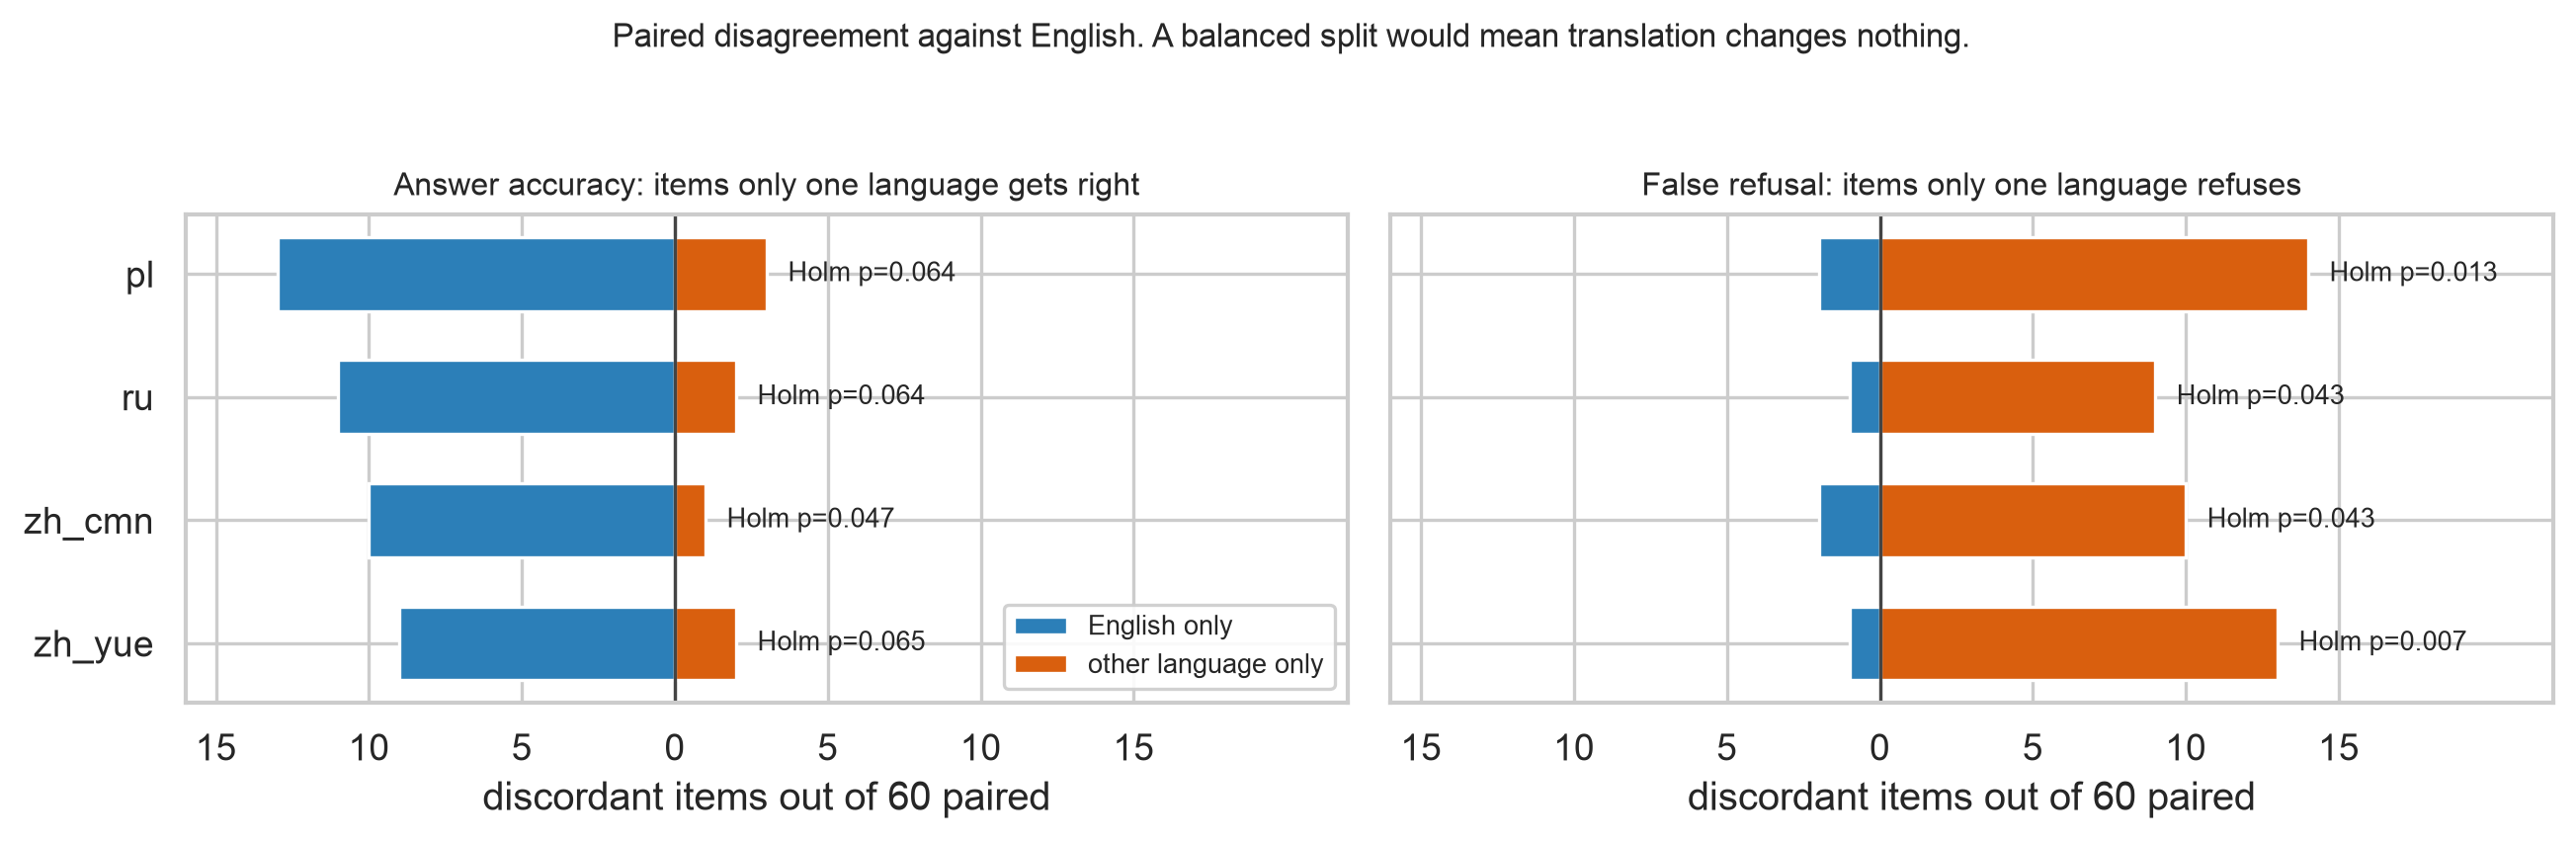

In [ ]:
# figure: 04-paired-language-disagreement
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
panels = [('answer_accuracy', 'Answer accuracy: items only one language gets right'), ('false_refusal_rate', 'False refusal: items only one language refuses')]
for _ax, (_metric, _title) in zip(_axes, panels):
    _sub = paired_stats[paired_stats['metric'] == _metric].set_index('language').loc[LANG_ORDER]
    _y = np.arange(len(_sub))[::-1]
    _ax.barh(_y, -_sub['en_only'], color='#2c7fb8', height=0.6, label='English only')
    _ax.barh(_y, _sub['other_only'], color='#d95f0e', height=0.6, label='other language only')
    for _yi, (_, r) in zip(_y, _sub.iterrows()):
        _ax.text(r['other_only'] + 0.7, _yi, f"Holm p={r['p_holm']:.3f}", va='center', fontsize=8)
    _ax.axvline(0, color='#444', lw=1)
    _ax.set_yticks(_y, _sub.index)
    _ax.set_xlim(-16, 22)
    _ax.set_xticks([-15, -10, -5, 0, 5, 10, 15])
    _ax.set_xticklabels([15, 10, 5, 0, 5, 10, 15])
    _ax.set_title(_title, fontsize=9.5)
    _ax.set_xlabel('discordant items out of 60 paired')
_axes[0].legend(fontsize=8, loc='lower right', framealpha=0.9)
_fig.suptitle('Paired disagreement against English. A balanced split would mean translation changes nothing.', y=1.04, fontsize=10)
plt.tight_layout()
plt.show()

The two panels behave differently, and that split matters more than either number alone.

**False refusal is the finding.** Count the discordant items, out of 60 paired in each language: Polish refuses 14 that English answers against 2 the other way, Cantonese 13 against 1, Mandarin 10 against 2, Russian 9 against 1. Every one is lopsided in the same direction. As rates that is 0.150 in English against 0.283 to 0.350 elsewhere, and all four clear Holm correction (adjusted 0.007 to 0.043). The unpaired view could only report that four languages pointed the same way. This measures it.

**Answer accuracy moves the same way, but the evidence is thinner.** All four languages drop against English, 0.667 down to 0.500 - 0.550, and the discordance leans the same way everywhere (13 against 3 in Polish, down to 9 against 2 in Cantonese). Three languages are below 0.05 unadjusted (0.012 to 0.023) and Cantonese is not (0.065). After Holm correction only Mandarin remains (0.047). Report the direction, not the size.

**Refusal accuracy does not move at all.** The discordant counts are near balanced in every language - 10 against 6, 7 against 11, 6 against 8, 8 against 10 - and every p value is above 0.45. Translation changes how readily the model answers, not how it names the reason when it declines. That fits section 4: the choice of code is dominated by the collapse onto `INFO_MISSING`, which is a property of the model, not of the language.

**This also splits the judge-noise caveat from section 2 in two.** It applies to `answer_accuracy`, which is gated on the quality score judges only agree on at Spearman 0.67 to 0.70. It does not apply to false refusal, which is a pure classification outcome where they agree at kappa 0.99. The cell below checks that directly, rerunning the paired test under each judge alone with no consensus pooling.

In [ ]:
merged = pd.read_csv(EVAL / 'judgments_merged.csv')
merged = merged[merged['status'] == 'ok']
judge_ans = merged[merged['ground_truth_label'] == ANSWER_CORRECTLY].copy()
judge_ans['refused'] = judge_ans['model_predicted_type'].astype(str).isin(REFUSAL_CODES)
_rows = []
for judge, _g in judge_ans.groupby('judge_id'):
    _wide = _g.pivot(index='id', columns='language', values='refused').astype(bool)
    for _lg in LANG_ORDER:
        _, _, _p = mcnemar_exact(_wide['en'], _wide[_lg])
        _rows.append({'judge': judge, 'language': _lg, 'false_refusal_rate': _wide[_lg].mean(), 'p': _p})
judge_paired = pd.DataFrame(_rows)
print('false refusal rate by judge, no consensus pooling')
print(judge_paired.pivot(index='judge', columns='language', values='false_refusal_rate').assign(en=[judge_ans[judge_ans['judge_id'] == j].pipe(lambda d: d[d['language'] == 'en']['refused'].mean()) for j in sorted(judge_ans['judge_id'].unique())])[['en'] + LANG_ORDER].round(3).to_string())
print()
print('unadjusted McNemar p against English, per judge')
print(judge_paired.pivot(index='judge', columns='language', values='p').round(4).to_string())
print()
print('worst p across all 12 judge-by-language tests: %.4f' % judge_paired['p'].max())

false refusal rate by judge, no consensus pooling
language            en    pl     ru  zh_cmn  zh_yue
judge                                              
mistral-large-3   0.15  0.35  0.317   0.283   0.350
nemotron-3-super  0.15  0.35  0.283   0.283   0.333
sonnet4_5         0.15  0.35  0.283   0.283   0.350

unadjusted McNemar p against English, per judge
language              pl      ru  zh_cmn  zh_yue
judge                                           
mistral-large-3   0.0042  0.0020  0.0386  0.0018
nemotron-3-super  0.0042  0.0215  0.0386  0.0034
sonnet4_5         0.0042  0.0215  0.0386  0.0018

worst p across all 12 judge-by-language tests: 0.0386


Every judge reproduces the effect in every language on its own, and the weakest of the twelve tests still lands at 0.039. The false refusal result is not an artefact of judge choice, nor of majority pooling.

That makes it the one result in this pilot that is both measured on the answerable side, so untouched by the label collapse, and independent of the quality score, so untouched by the one place the judges genuinely disagree. It is the finding to carry forward.

## 6. Perturbation class

Split by component, because pooling across intensities would mix the answerable third with the unanswerable two-thirds.

                     answer_accuracy  refusal_accuracy  false_refusal_rate  missed_refusal_rate  calibrated_refusal_score
perturbation                                                                                                             
FalsePremise                    0.22              0.07                0.66                 0.02                     0.145
GranularityMismatch             0.54              0.00                0.22                 0.09                     0.270
EpistemicMismatch               0.44              0.36                0.34                 0.08                     0.400
Ambiguity                       0.76              0.17                0.10                 0.47                     0.465
Contradiction                   0.74              0.40                0.12                 0.18                     0.570
MissingInfo                     0.60              0.84                0.26                 0.16                     0.720


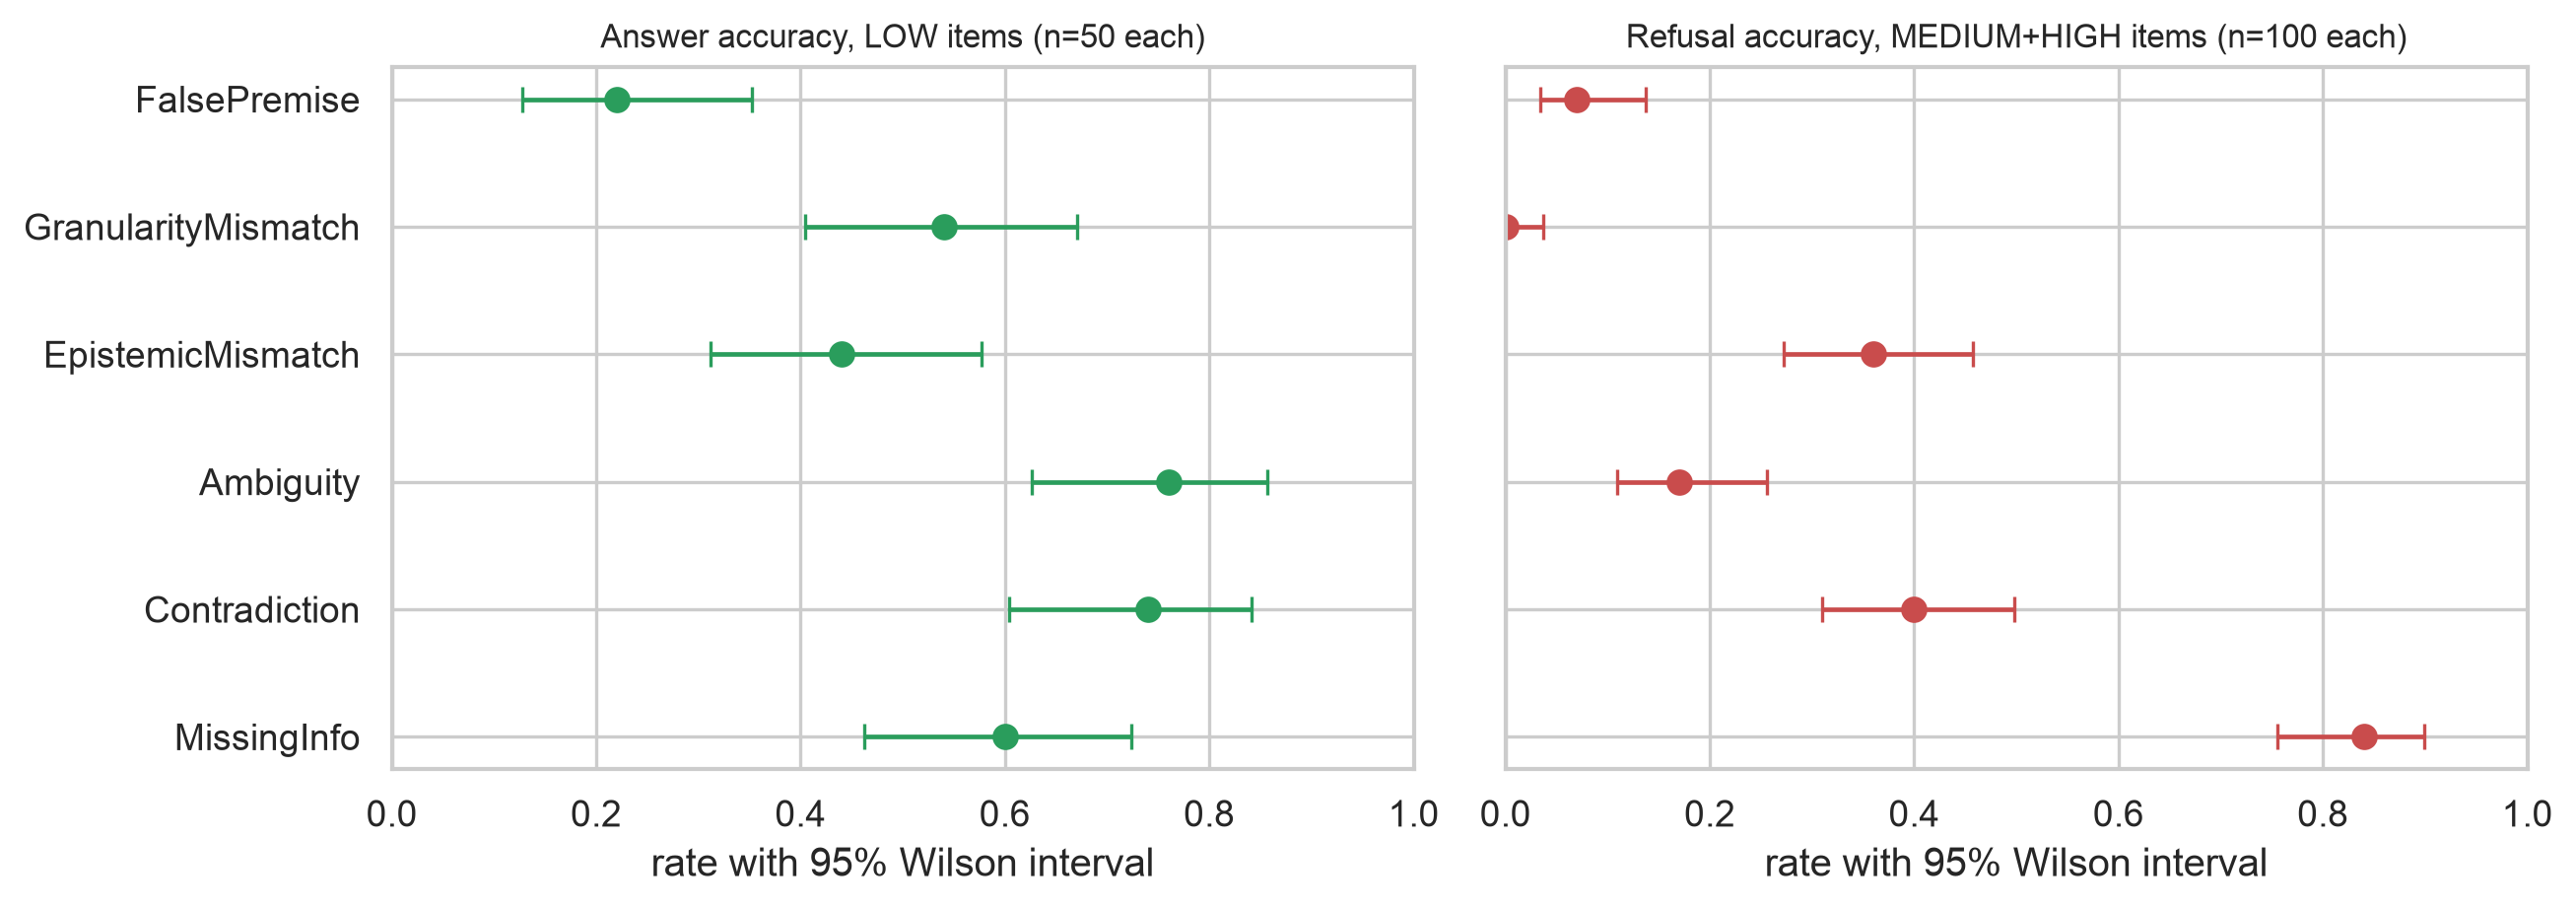

In [ ]:
# perturbation classes also span all three intensities, so both populations are present.
pert_rows = []
for pert, _g in consensus.groupby('perturbation_class'):
    _block = compute_metrics_block(_g)
    _a = _g[_g['answerable']]
    _u = _g[~_g['answerable']]
    _n_ans = int((_a['model_predicted_type'].eq('answer_attempt') & (_a['answer_quality_score'] >= 4)).sum())
    _n_ref = int(_u['refusal_match_correct'].eq(True).sum())
    pert_rows.append({'perturbation': pert.replace('P-', ''), 'answer_accuracy': _block['answer_accuracy'], 'ans_ci': wilson(_n_ans, len(_a)), 'refusal_accuracy': _block['refusal_accuracy'], 'ref_ci': wilson(_n_ref, len(_u)), 'false_refusal_rate': _block['false_refusal_rate'], 'missed_refusal_rate': _block['missed_refusal_rate'], 'calibrated_refusal_score': _block['calibrated_refusal_score']})
pert = pd.DataFrame(pert_rows).set_index('perturbation').sort_values('calibrated_refusal_score')
print(pert[['answer_accuracy', 'refusal_accuracy', 'false_refusal_rate', 'missed_refusal_rate', 'calibrated_refusal_score']].round(3).to_string())
# figure: 05-perturbation-class
_fig, _axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
_y = np.arange(len(pert))[::-1]
for _ax, (_point, _ci, _title, _colour) in zip(_axes, [('answer_accuracy', 'ans_ci', 'Answer accuracy, LOW items (n=50 each)', '#2a9d5c'), ('refusal_accuracy', 'ref_ci', 'Refusal accuracy, MEDIUM+HIGH items (n=100 each)', '#c94c4c')]):
    _lo = np.array([_c[0] for _c in pert[_ci]])
    _hi = np.array([_c[1] for _c in pert[_ci]])
    _ax.errorbar(pert[_point], _y, xerr=[pert[_point] - _lo, _hi - pert[_point]], fmt='o', color=_colour, capsize=4, markersize=7, lw=1.4)
    _ax.set_yticks(_y, pert.index)
    _ax.set_xlim(0, 1)
    _ax.set_title(_title, fontsize=10)
    _ax.set_xlabel('rate with 95% Wilson interval')
plt.tight_layout()
plt.show()

Here the effects are large enough to survive the interval check, and the two panels tell different stories.

**Refusal side.** The spread runs from 0.00 (Granularity) to 0.84 (MissingInfo) and the intervals do not overlap. But section 4 already explained the mechanism: MissingInfo scores 0.84 because its ground-truth code is the label the model defaults to, and Granularity scores 0.00 because its code is never emitted. **This ranking shows which codes the model uses, not which perturbations are hard.** Reporting "the model finds granularity mismatch hardest" would be wrong. The honest statement is that the model does not have a granularity refusal behaviour at all.

**Answer side.** This panel is not affected by the collapse. FalsePremise answerable items score 0.220 against 0.740 to 0.760 for Contradiction and Ambiguity, driven by a false refusal rate of 0.660.

**Two caveats have to travel with that number, and both are easy to miss.**

First, on what the items are. These are LOW FalsePremise items, and the intro cell described what that means: the query really does contain a false presupposition, and the ground truth is nonetheless to answer the part the context supports. So the correct reading is not "the model refuses clean questions". It is "when a query contains a false presupposition alongside an answerable request, the model refuses two thirds of the time instead of answering the answerable part". Whether that should count as a failure is a genuine question about the benchmark's ground truth, not only about the model. It is still a real over-refusal signal, because the other five perturbation classes carry LOW-level defects too and refuse far less often.

Second, on the sample. The 0.220 and 0.660 are computed over 50 rows, but those 50 rows are **10 base items seen in five languages**, not 50 independent items. Section 1 warned that 10 items per cell is too few to separate anything, and that warning applies here. Treat the size of this effect as unmeasured and the direction as worth following up.

## 7. Intensity, using only the comparison the design permits

MEDIUM and HIGH are both entirely unanswerable and carry identical ground-truth code distributions (50 items per code each), so they can be compared directly on the unanswerable metrics.

This is a design check rather than a finding. The RefusalBench paper defines MEDIUM as a clear informational deficit and HIGH as a severe one, often a logical paradox, so HIGH items are *meant* to be easier to detect and the paper reports refusal rates rising with intensity. The question worth asking here is the one the design does not answer on its own: when the defect is made more obvious, does the model also get better at naming it?

ground-truth codes by intensity, unanswerable only
intensity                       HIGH  MEDIUM
ground_truth_label                          
REFUSE_AMBIGUOUS_QUERY            50      50
REFUSE_CONTRADICTORY_CONTEXT      50      50
REFUSE_FALSE_PREMISE_IN_QUERY     50      50
REFUSE_GRANULARITY_MISMATCH       50      50
REFUSE_INFO_MISSING_IN_CONTEXT    50      50
REFUSE_NONFACTUAL_QUERY           50      50

counts out of 300 unanswerable items at each level
           declined  right_code  answered_anyway  info_missing  right_code_given_declined
intensity                                                                                
MEDIUM          239          79               61           182                      0.331
HIGH            261         105               39           182                      0.402

HIGH minus MEDIUM, as rates (z in brackets, unadjusted)
  refusal accuracy:    0.350 vs 0.263   [z = +2.30]
  missed refusal rate: 0.130 vs 0.203   [z = -2.41]


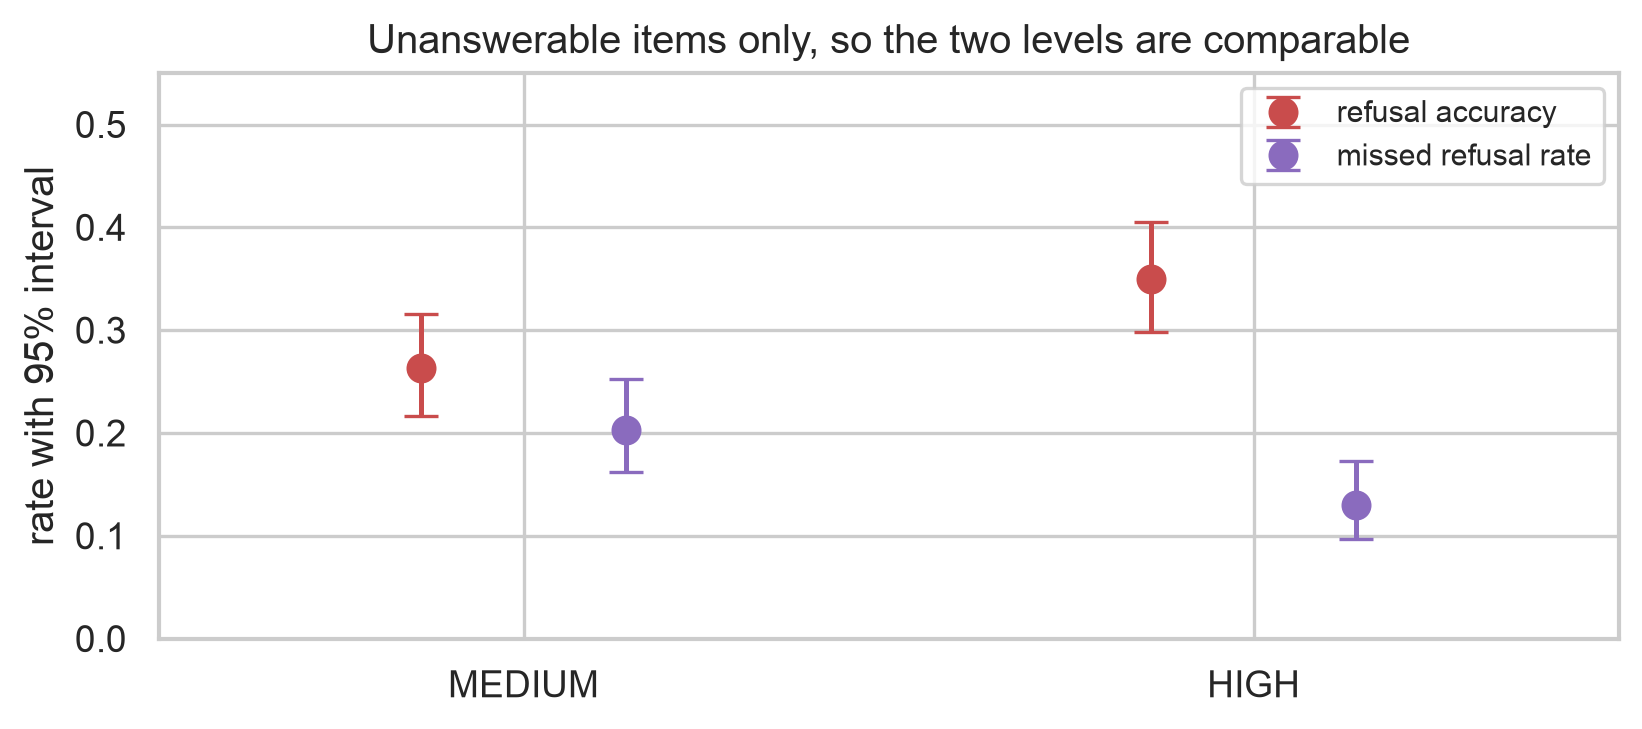

In [ ]:
print('ground-truth codes by intensity, unanswerable only')
print(pd.crosstab(unanswerable['ground_truth_label'], unanswerable['intensity']).to_string())
print()
_rows = []
for lvl in ['MEDIUM', 'HIGH']:
    _g = unanswerable[unanswerable['intensity'] == lvl]
    _n_ref = int(_g['refusal_match_correct'].eq(True).sum())
    n_miss = int(_g['model_predicted_type'].eq('answer_attempt').sum())
    n_declined = len(_g) - n_miss
    n_info = int(_g['model_predicted_type'].eq('REFUSE_INFO_MISSING_IN_CONTEXT').sum())
    _rows.append({'intensity': lvl, 'n': len(_g), 'declined': n_declined, 'right_code': _n_ref, 'answered_anyway': n_miss, 'info_missing': n_info, 'right_code_given_declined': _n_ref / n_declined, 'refusal_accuracy': _n_ref / len(_g), 'refusal_ci': wilson(_n_ref, len(_g)), 'missed_refusal_rate': n_miss / len(_g), 'missed_ci': wilson(n_miss, len(_g))})
inten = pd.DataFrame(_rows).set_index('intensity')
print('counts out of 300 unanswerable items at each level')
print(inten[['declined', 'right_code', 'answered_anyway', 'info_missing', 'right_code_given_declined']].round(3).to_string())

def two_prop_z(p1, n1, p2, n2):
    pooled = (p1 * n1 + p2 * n2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))  # naming skill conditional on having declined, which detection cannot inflate
    return (p1 - p2) / se
print()
print('HIGH minus MEDIUM, as rates (z in brackets, unadjusted)')
print('  refusal accuracy:    %.3f vs %.3f   [z = %+.2f]' % (inten.loc['HIGH', 'refusal_accuracy'], inten.loc['MEDIUM', 'refusal_accuracy'], two_prop_z(inten.loc['HIGH', 'refusal_accuracy'], 300, inten.loc['MEDIUM', 'refusal_accuracy'], 300)))
print('  missed refusal rate: %.3f vs %.3f   [z = %+.2f]' % (inten.loc['HIGH', 'missed_refusal_rate'], inten.loc['MEDIUM', 'missed_refusal_rate'], two_prop_z(inten.loc['HIGH', 'missed_refusal_rate'], 300, inten.loc['MEDIUM', 'missed_refusal_rate'], 300)))
_fig, _ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(2)
for i, (_metric, _ci, label, _colour) in enumerate([('refusal_accuracy', 'refusal_ci', 'refusal accuracy', '#c94c4c'), ('missed_refusal_rate', 'missed_ci', 'missed refusal rate', '#8a6bbe')]):
    pos = x + (i - 0.5) * 0.28
    vals = inten[_metric].values
    _lo = np.array([_c[0] for _c in inten[_ci]])
    _hi = np.array([_c[1] for _c in inten[_ci]])
    _ax.errorbar(pos, vals, yerr=[vals - _lo, _hi - vals], fmt='o', capsize=5, markersize=8, lw=1.5, color=_colour, label=label)
_ax.set_xticks(x, ['MEDIUM', 'HIGH'])
_ax.set_xlim(-0.5, 1.5)
_ax.set_ylim(0, 0.55)
_ax.set_ylabel('rate with 95% interval')
_ax.set_title('Unanswerable items only, so the two levels are comparable')
_ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Out of 300 unanswerable items at each level, HIGH is detected more readily: the model declines on **261** against **239**, and gets the right code on **105** against **79**. Both gaps sit around p = 0.02 unadjusted and this notebook runs many comparisons, so they are suggestive rather than established. They are also the direction the perturbation engine intends, since a severe defect is easier to spot than a clear one, so this confirms the design behaves as specified. It is not evidence that HIGH items are harder, and no difficulty ranking should be read off intensity.

**The default label does not move with it.** `INFO_MISSING` is emitted exactly **182 times at each level**. All 22 of the extra refusals at HIGH went to some other code, which is most of why the right-code count rises. Conditional on having declined, the model names the reason correctly 0.402 of the time at HIGH against 0.331 at MEDIUM - some improvement, but the one code it over-uses stays at the same absolute count no matter how obvious the defect.

That is section 4's collapse holding fixed across the only axis the design varies deliberately, which makes it a property of the model rather than of item difficulty. It is also the clearest evidence in the pilot that detection and categorisation are separate skills here: making the problem more visible moves the first and barely touches the second.

**This corroborates the paper's central claim about refusal, from a different direction.** RefusalBench section 4.2, under the heading *Refusal Comprises Two Distinct Skills*, argues that refusal splits into detection (knowing *when* to refuse) and categorisation (knowing *why*), and shows models that have one without the other. The paper establishes this by comparing models against each other. This pilot sees the same split inside a single model along an axis the paper does not use: raising the severity of the defect changes whether the model refuses without changing which label it reaches for.

## 8. Conclusions

### What the pilot establishes

1. **The judges are reliable for classification and unreliable for quality.** Cohen kappa 0.984 to 0.993 and Fleiss 0.990 on refusal codes, against Spearman 0.67 to 0.70 on the 1 to 5 quality score. Consensus classification labels can be pooled without concern. Anything gated on the quality threshold, which means `answer_accuracy` and therefore `calibrated_refusal_score`, carries judge noise worth up to 0.058 in the final score. On the ensemble question this is the answer: a single judge would give practically the same refusal codes, and the ensemble earns its cost only on the quality gate.

2. **The model collapses its refusal vocabulary onto one code.** 61 percent of predictions on unanswerable items are `REFUSE_INFO_MISSING_IN_CONTEXT`, against a 17 percent ground-truth prevalence. `REFUSE_GRANULARITY_MISMATCH` is never emitted once in 900 items despite being the ground truth for 100 of them, so those items score zero by construction. This is the dominant fact about the run and it contaminates every `refusal_accuracy` figure downstream.

3. **Translation makes the model refuse answerable questions it would answer in English.** On the identical 180 items, false refusal rises from 0.150 in English to between 0.283 and 0.350 in the other four languages. The paired disagreement is one-sided in every language - 14 against 2 in Polish, 13 against 1 in Cantonese, out of 60 - and all four clear Holm correction (adjusted 0.007 to 0.043). Every judge reproduces it alone, worst p 0.039 across all twelve judge-by-language tests, so it is neither a consensus artefact nor a judge-choice artefact. Measured on the answerable side, it is also untouched by the label collapse in point 2. This is the strongest result in the pilot.

4. **False-premise framing is associated with heavy over-refusal, on very few items.** Answerable items in the FalsePremise class score 0.220 answer accuracy with a 0.660 false refusal rate, against 0.740 to 0.760 accuracy for Contradiction and Ambiguity. Like point 3 this is measured on the answerable side, so it is not an artefact of the label collapse. Two limits, both from section 6: it rests on 10 base items seen in five languages, so the size is unmeasured, and these queries do contain a genuine false presupposition, so "refuses clean questions" would misdescribe them.

5. **The model detects unanswerability far better than it explains it.** It declines on 500 of 600 unanswerable items but names the right reason on only 184. Section 7 separates the two skills directly: making the defect more severe moves detection and leaves the over-used code at exactly 182 emissions per level. This is the same detection-versus-categorisation split the RefusalBench paper reports in section 4.2, reached here along an axis the paper does not use.

6. **Translation does not change how the model names its refusals.** Paired refusal accuracy is flat across languages, all four p values above 0.45 with near balanced discordance (10 against 6 in Polish, 7 against 11 in Russian, 6 against 8 in Mandarin, 8 against 10 in Cantonese). The degradation in point 3 is entirely about willingness to answer, not about refusal reasoning. Reported as `FINDINGS.md` section 2.5.

### What the pilot does not establish

7. **The size of the language effect, or a ranking between the four languages.** The paired test establishes the direction and that it is real. It does not pin the magnitude: on answer accuracy three of the four languages are individually significant and Cantonese is not (0.065), only Mandarin survives Holm correction, and the marginal calibrated-score gaps of 0.050 to 0.100 sit close to the 0.058 that judge choice alone moves. Report "translation degrades selective refusal, driven by over-refusal", and no more than that.

8. **The perturbation difficulty ranking on the refusal side.** MissingInfo at 0.84 and Granularity at 0.00 reflect which codes the model owns, not which perturbations are hard. Do not report this ranking as difficulty.

9. **Any intensity story beyond detection.** LOW is the answerable stratum and is not on the same scale as MEDIUM and HIGH. The confound comes from the parent benchmark's own design (paper section 3.3) rather than from this pilot. On the comparison that is valid, MEDIUM against HIGH within unanswerable items, HIGH is the level the model detects more readily (261 declines against 239, 105 right codes against 79, out of 300 each). That is what the perturbation design intends rather than a finding about the model, and it is unadjusted for multiple comparisons. Intensity is a detection axis here, not a difficulty axis.

10. **Anything at stratum granularity.** 10 items per cell gives a 95 percent interval about half the scale wide, and all 90 stratum rows are pure so they carry no calibrated score at all.

### Recommended changes before scaling up (by Claude Opus 5)

11. **Keep the paired design and analyse it as paired.** Translating the same items rather than sampling fresh ones per language is what makes point 3 reachable at n=60. An unpaired reading of the same data finds nothing. Any scaled-up run should preserve the shared item set, and the metrics files should carry the item ID so paired tests stay possible downstream.

12. **Break the answerability and intensity confound.** Put answerable controls at every intensity, or stop calling the answerable stratum an intensity level. As built, no intensity conclusion is reachable.

13. **Report `answer_accuracy` and `refusal_accuracy` separately and retire the pooled calibrated score,** or at minimum publish it only alongside both components. Averaging a judge-noise-dominated metric with a label-collapse-dominated metric produces a number whose movements cannot be attributed. Points 3 and 6 are a concrete case: the two components move independently and the average hides that.

14. **Compute the paper's own refusal metrics, which our pipeline does not.** Appendix D of RefusalBench already defines Refusal Detection F1, Category Accuracy (the reason given a correct decision to refuse) and the Hierarchical Refusal Score that multiplies the two. `aggregate.py` emits none of them, so an exact code match currently scores a correctly detected refusal as a total failure whenever the code is wrong, which is 316 of 500 detections here. Section 7 shows detection and categorisation move independently, so one number cannot track both.

15. **Spend the extra items on answer quality, not on more languages.** False refusal already resolves at n=60 per language. Answer accuracy does not, because it is gated on the one judgment the judges disagree about, so more items and a tighter quality rubric would buy more than a fifth and sixth language would.

### Robustness checks completed since

16. **English leakage in the model's input does not explain point 3.** [`pilot_v2_leakage_subsets.ipynb`](pilot_v2_leakage_subsets.ipynb) finds the cross-language gap grows on lower-leakage items rather than shrinking. The direction is consistent across four of five ways of splitting the 60 answerable items, across leakage tertiles on two measures, and in both rank correlations. The size is not pinned down: permutation p ranges from 0.034 to 0.90 depending on how "low leakage" is defined, so read this as leakage failing to explain the effect and probably diluting it, not as a measured dilution of a given size.

17. **The judge's prompt language does not explain point 3 either.** [`pilot_v2_judge_prompt_language.ipynb`](pilot_v2_judge_prompt_language.ipynb) re-runs the whole evaluation with `--judge-prompt-language target`, so each language is judged in its own language, and compares it against this run. Consensus labels are identical on 896 of 900 items, the largest consensus metric change on any language is 0.017 against the 0.058 judge-swap swing in point 1, and all four languages still clear Holm correction on the paired false refusal test. Point 2's label collapse is unchanged too, so it is a property of the evaluated model rather than of English-instructed judging. Every number in this notebook stands as written.